In [1]:
import scanpy as sc

import sys
sys.path.append('../../1_figure_CL_proof_of_concept/code/')
import utils_00 as gf_utils

large_data_dir = gf_utils.large_data_dir

import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
import matplotlib.pyplot as plt

import pandas as pd
import numpy as np

In [ ]:
adata_path = large_data_dir + 'GBM_BC002_genotyped.h5ad'
adata = sc.read_h5ad(adata_path)

In [3]:
macrophage_genes = ['CD14', 'AIF1', 'FCER1G', 'FCGR3A', 'TYROBP', 'CSF1R'] ### Neftel 2019
oligodendrocyte_genes = ['MBP', 'TF', 'PLP1', 'MAG', 'MOG', 'CLDN11'] ### Neftel 2019
T_cell_genes = ['CD2', 'CD3D', 'CD3E', 'CD3G'] ### Neftel 2019
endothelial_genes = ['IL32', 'CD93', 'BGN', 'IGFBP7'] ### Bhaduri Nature 2020
neuronal_genes = ['RBFOX3','SLC17A7','SATB2'] ### excitatory neuron markers from Lake et al Science 2016

all_marker_genes = macrophage_genes + oligodendrocyte_genes + T_cell_genes + endothelial_genes + neuronal_genes
all_marker_genes = [gene for gene in all_marker_genes if gene in adata.var.index]

In [4]:
adata.obs['cell_type'] = pd.read_csv('../../3_figure_FFPE/output/GBM_cell_type_labels.txt', sep='\t', index_col=0)['cell_type']

/data1/lareauc/users/blattms/miniconda3/envs/gift_paper/lib/python3.11/site-packages/anndata/_core/anndata.py:1158: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


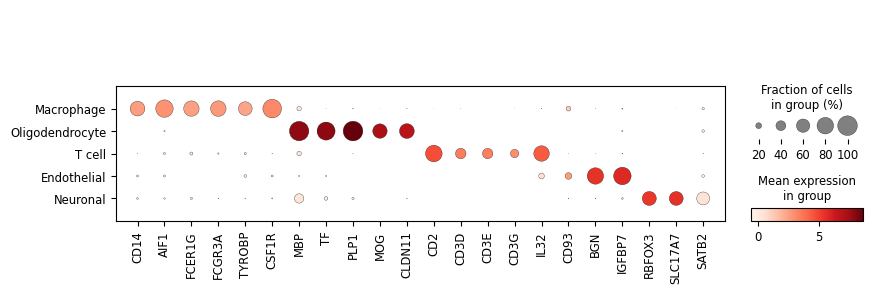

In [5]:
nonmalignant_cell_types = ['Macrophage','Oligodendrocyte','T cell','Endothelial','Neuronal']
sc.pl.dotplot(
    adata[adata.obs['cell_type'].isin(nonmalignant_cell_types)],
    var_names=all_marker_genes,
    groupby='cell_type',
    layer='zs_norm_log',
    categories_order=nonmalignant_cell_types, show=False
)

plt.savefig('../plots/cell_type_markers.pdf')


In [6]:
### then label GBM states using Neftel gene sets
GBM_gene_sets = pd.read_excel('../../3_figure_FFPE/data/Neftel_GBM_modules.xlsx')

col_names = []
modules = ['MES','AC','OPC','NPC']
for gene_set in modules:
    genes = GBM_gene_sets.loc[:,GBM_gene_sets.columns.str.contains(gene_set)].values.flatten()
    gf_utils.define_gene_score(adata, genes, gene_set, rename=False)
    col_names.append('gene_score_' + gene_set)

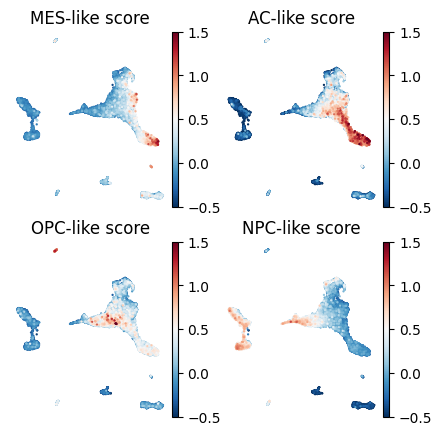

In [7]:
fig, ax = plt.subplots(2, 2, figsize=(5,5))
for module in modules:
    sc.pl.umap(adata, color='gene_score_' + module, show=False, vmin=-0.5, vmax=1.5, cmap='RdBu_r', ax=ax.flatten()[modules.index(module)], title = module + '-like score', frameon=False)
plt.savefig('../plots/GBM_state_markers.pdf')